<a href="https://colab.research.google.com/github/Kuoz2/An-lisis_y_Predicci-n/blob/main/EDA_dataset4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style='whitegrid')

In [3]:
dk_ecommerce= pd.read_csv("/content/drive/MyDrive/CURSOPYTHON/ecommerce_customer_behavior_5000.csv")
print(f"Tamaño del dataset: {dk_ecommerce.shape[0]} filas y {dk_ecommerce.shape[1]} columnas.\n")

Tamaño del dataset: 5000 filas y 10 columnas.



In [4]:
dk_ecommerce.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            5000 non-null   int64  
 1   customer_age        5000 non-null   int64  
 2   customer_gender     5000 non-null   object 
 3   product_category    5000 non-null   object 
 4   payment_method      5000 non-null   object 
 5   order_value_usd     5000 non-null   float64
 6   delivery_time_days  5000 non-null   int64  
 7   customer_rating     5000 non-null   float64
 8   returned            5000 non-null   object 
 9   order_date          5000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 390.8+ KB


In [5]:
dk_ecommerce.describe()

,order_id,customer_age,order_value_usd,delivery_time_days,customer_rating
count,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000
mean,2500.500000,43.263400,749.672238,7.47300,3.015720
std,1443.520003,15.000847,430.370938,4.03293,1.148516
min,1.000000,18.000000,5.570000,1.00000,1.000000
25%,1250.750000,30.000000,367.087500,4.00000,2.000000
50%,2500.500000,43.000000,760.285000,7.00000,3.000000
75%,3750.250000,56.000000,1120.752500,11.00000,4.000000
max,5000.000000,69.000000,1499.370000,14.00000,5.000000


In [6]:
dk_ecommerce.head()

,order_id,customer_age,customer_gender,product_category,payment_method,order_value_usd,delivery_time_days,customer_rating,returned,order_date
0,1,37,Other,Home & Living,Wallet,1366.60,10,2.3,No,2022-01-01
1,2,41,Female,Fashion,Cash on Delivery,1175.89,6,1.8,Yes,2022-01-02
2,3,30,Other,Sports,Debit Card,1283.97,7,3.2,No,2022-01-03
3,4,58,Female,Electronics,Credit Card,1245.76,14,3.8,No,2022-01-04
4,5,59,Other,Fashion,Cash on Delivery,1411.06,7,3.2,No,2022-01-05


In [7]:
dk_ecommerce.tail(5)

,order_id,customer_age,customer_gender,product_category,payment_method,order_value_usd,delivery_time_days,customer_rating,returned,order_date
4995,4996,18,Female,Groceries,Credit Card,420.44,7,1.3,Yes,2035-09-05
4996,4997,19,Male,Sports,UPI,1389.97,2,1.2,Yes,2035-09-06
4997,4998,42,Male,Sports,Credit Card,845.66,4,1.3,Yes,2035-09-07
4998,4999,46,Other,Sports,Credit Card,1077.51,3,2.6,Yes,2035-09-08
4999,5000,60,Male,Sports,UPI,290.47,8,1.5,Yes,2035-09-09


In [8]:
display(dk_ecommerce.isnull().sum())

,0
order_id,0
customer_age,0
customer_gender,0
product_category,0
payment_method,0
order_value_usd,0
delivery_time_days,0
customer_rating,0
returned,0
order_date,0


In [12]:
for col in dk_ecommerce.select_dtypes(include=['object']).columns:
  dk_ecommerce[col]= dk_ecommerce[col].astype(str).str.strip().str.upper()


In [13]:
valores_nulos= ['', ' ', '-', 'N/A', 'NA', 'NONE', 'NULL', 'NAN', 'DESCONOCIDO']

dk_ecommerce.replace(valores_nulos, np.nan, inplace=True)

nulo_real= dk_ecommerce.isnull().sum()
if nulo_real.sum() >0:
  display(nulo_real[nulo_real > 0])

  for col in dk_ecommerce.select_dtypes(includes=[np.number]).columns:
    dk_ecommerce[col].fillna(dk_ecommerce[col].median(), inplace=True)
  for col in dk_ecommerce.select_dtypes(includes=['object']).columns:
    dk_ecommerce[col].fillna('SIN DATOS', inplace=True)
  print('Existen nulos no imputados')
else:
  print("El dataset esta totalmente limpio")

El dataset esta totalmente limpio


In [14]:
display(dk_ecommerce.describe().round(2))

display(dk_ecommerce.describe(include=['object']))

,order_id,customer_age,order_value_usd,delivery_time_days,customer_rating
count,5000.00,5000.00,5000.00,5000.00,5000.00
mean,2500.50,43.26,749.67,7.47,3.02
std,1443.52,15.00,430.37,4.03,1.15
min,1.00,18.00,5.57,1.00,1.00
25%,1250.75,30.00,367.09,4.00,2.00
50%,2500.50,43.00,760.29,7.00,3.00
75%,3750.25,56.00,1120.75,11.00,4.00
max,5000.00,69.00,1499.37,14.00,5.00


,customer_gender,product_category,payment_method,returned,order_date
count,5000,5000,5000,5000,5000
unique,3,6,5,2,5000
top,MALE,BEAUTY,UPI,YES,2035-09-09
freq,1709,853,1031,2525,1


In [16]:
col_obj= dk_ecommerce.select_dtypes(include=[np.number]).columns[-1]

q1= dk_ecommerce[col_obj].quantile(0.25)
q3= dk_ecommerce[col_obj].quantile(0.75)

IQR= q1-q3

limite_sup= q3 + 1.5 * IQR
limite_inf= q1 -1.5 * IQR

outlers= dk_ecommerce[(dk_ecommerce[col_obj]> limite_sup)|(dk_ecommerce[col_obj] < limite_inf) ]

print(f"Variable analizada: '{col_obj}'")
print(f"Se detectaron {len(outlers)} registros atípicos (valores extremos matemáticamente).")
print("Tratamiento sugerido: En E-Commerce, los outliers superiores representan clientes 'Premium' o compras mayoristas. NO se deben eliminar, sino agrupar en un clúster específico.")

Variable analizada: 'customer_rating'
Se detectaron 5000 registros atípicos (valores extremos matemáticamente).
Tratamiento sugerido: En E-Commerce, los outliers superiores representan clientes 'Premium' o compras mayoristas. NO se deben eliminar, sino agrupar en un clúster específico.


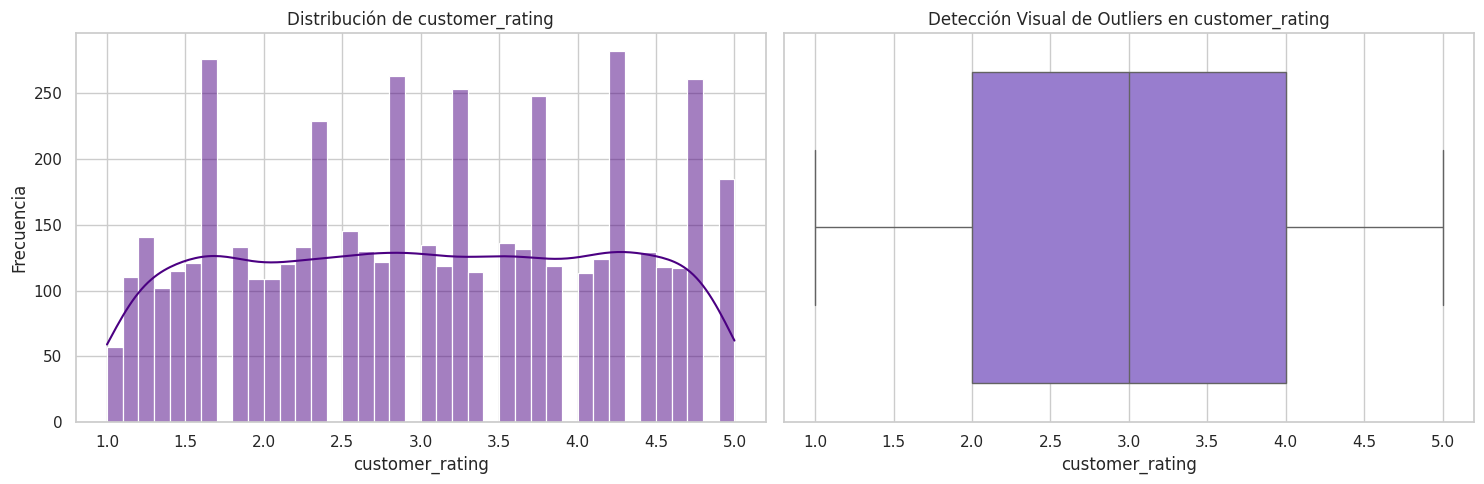

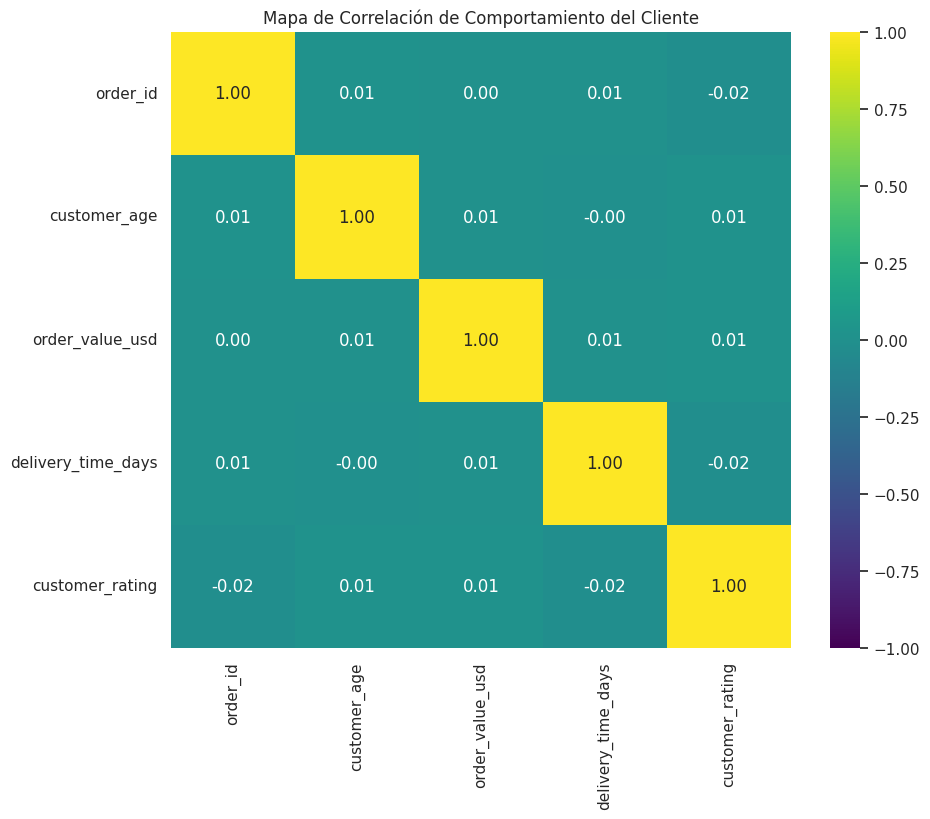

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(dk_ecommerce[col_obj], kde=True, bins=40, ax=axes[0], color='indigo')
axes[0].set_title(f'Distribución de {col_obj}')
axes[0].set_ylabel('Frecuencia')

sns.boxplot(x=dk_ecommerce[col_obj], ax=axes[1], color='mediumpurple')
axes[1].set_title(f'Detección Visual de Outliers en {col_obj}')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
num_cols = dk_ecommerce.select_dtypes(include=[np.number])

if len(num_cols.columns) > 1:
    sns.heatmap(num_cols.corr(), annot=True, cmap='viridis', fmt=".2f", vmin=-1, vmax=1)
    plt.title('Mapa de Correlación de Comportamiento del Cliente')
    plt.show()
else:
    print("No hay suficientes variables numéricas para generar un mapa de calor.")